In [1]:
import numpy as np
import pandas as pd
import timecorr as tc
import hypertools as hyp
import supereeg as se
from matplotlib import pyplot as plt
from matplotlib import animation as ani
import seaborn as sns
import os
from glob import glob as lsdir
from scipy.io import loadmat as load
import numba
import nltools as nlt
import nilearn as nl
import nibabel as nib
from nilearn.input_data import NiftiMasker
from scipy.spatial.distance import pdist, cdist, squareform
from collections import deque
from IPython.display import HTML
import matlab.engine as mlab
import matlab

%matplotlib inline

/usr/local/Cellar/python/3.6.5_1/Frameworks/Python.framework/Versions/3.6/lib/python3.6/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216, got 192
  return f(*args, **kwds)
/usr/local/Cellar/python/3.6.5_1/Frameworks/Python.framework/Versions/3.6/lib/python3.6/importlib/_bootstrap.py:219: ImportWarning: can't resolve package from __spec__ or __package__, falling back on __name__ and __path__
  return f(*args, **kwds)


In [2]:
datadir = os.path.join(os.getenv('HOME'), 'data', 'fMRI', 'dffr')
nii_files = lsdir(os.path.join(datadir, '*.nii'))
regressor_files = lsdir(os.path.join(datadir, 'regmats', '*.mat'))
cluster_masks = os.path.join('clusters', 'k50_2mm_gm_split_cleaned.nii.gz')

In [3]:
def apply_mask(data, mask):
    data = data.get_data()
    mask = mask.get_data()
    
    T = data.shape[3]
    K = mask.shape[3]    
    Y = np.zeros([T, K])
    
    for k in np.arange(K):
        roi_mask = mask[:, :, :, k]
        roi_inds = np.where(roi_mask)
        Y[:, k] = np.mean(data[roi_inds[0], roi_inds[1], roi_inds[2], :], axis=0)
    return Y

In [4]:
def plot_cluster_centers(mask, node_color='k', node_size=10, **kwargs):
    mask_bo = se.Brain(mask)
    data = mask_bo.data
    locs = mask_bo.locs
    
    centers = np.zeros([data.shape[0], locs.shape[1]])
    widths = np.zeros([data.shape[0], 1])
    
    for k in np.arange(data.shape[0]):
        centers[k, :] = locs.iloc[np.where(data.iloc[k, :] == 1)[0], :].mean(axis=0)
        widths[k] = np.sqrt(((locs.iloc[np.where(data.iloc[k, :] == 1)[0], :] - centers[k, :]) ** 2).sum(axis=1)).mean(axis=0)
    
    nl.plotting.plot_connectome(np.eye(centers.shape[0]), centers, node_color=node_color, node_size=(widths ** 2) / 10, **kwargs)
    return centers, widths

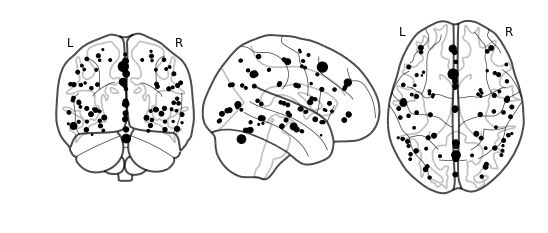

In [5]:
mask = nib.load(cluster_masks)
centers, widths = plot_cluster_centers(mask)

In [6]:
def package_data(masked_data, nii_files, regressor_files):
    nii_subjs = list(map(lambda f: f.split('/')[-1][:-len('.nii')], nii_files))
    reg_subjs = list(map(lambda f: f.split('/')[-1][:-len('_regs_results.mat')], regressor_files))
    
    data = []
    for i, s in enumerate(nii_subjs):
        try:
            j = np.ravel(np.where(np.array(list(map(lambda x: x == s, reg_subjs)))))[0]
            print(f'matching {s} with {regressor_files[j]}')
            regmat = load(regressor_files[j])
            data.append({'data': masked_data[i], 'regmat': regmat['all_regressors'], 'mvpa': regmat['results']})
        except:
            print(f'missing data for {s}')
    return data

In [7]:
data_fname = os.path.join('data', 'preprocessed.npz')
if os.path.exists(data_fname):
    print('loading preprocessed data from disk...')
    data = np.load(data_fname)['data']
else:
    print('preprocessed data...')
    masked_data = list(map(lambda f: apply_mask(nib.load(f), mask), nii_files))
    data = package_data(masked_data, nii_files, regressor_files)
    np.savez(os.path.join('data', 'preprocessed.npz'), data=data)

loading preprocessed data from disk...


In [8]:
regressors_key = ['Present list A', 
                  'Present list B (R)', 
                  'Present list B (F)',
                  'Recall list A (R)',
                  'Recall list B (R)', 
                  'Recall list A (F)',
                  'Recall list B (F)',
                  'Present localizer list 1',
                  'Recall localizer list 1',
                  'Present localizer list 2',
                  'Recall localizer list 2',
                  'Present scene localizer image',
                  'Present objects localizer image',
                  'Present scrambled scene localizer image']
present_a = [0]
present_b = [1, 2]
forget = [2, 5, 6]
remember = [1, 3, 4]

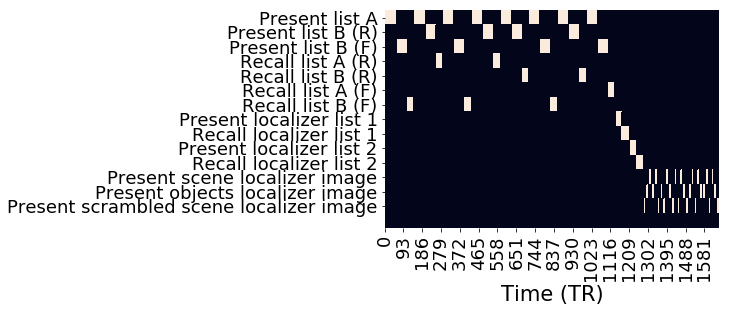

In [9]:
#experiment labels from participant 0
h = sns.heatmap(data[0]['regmat'], cbar=False)
h.set_yticks(np.arange(len(regressors_key)) + 0.5)
h.set_yticklabels(regressors_key)
plt.yticks(rotation=0);
plt.xlabel('Time (TR)');

In [10]:
def get_keys(inds):
    keys = []
    for i in inds:
        keys.append(regressors_key[i])
    return keys

In [11]:
print(get_keys(present_a))
print(get_keys(present_b))
print(get_keys(remember))
print(get_keys(forget))

['Present list A']
['Present list B (R)', 'Present list B (F)']
['Present list B (R)', 'Recall list A (R)', 'Recall list B (R)']
['Present list B (F)', 'Recall list A (F)', 'Recall list B (F)']


In [12]:
def get_bounds(x): #x is a line from a regressors matrix
    diffs = np.diff(np.array(x, dtype=np.float)) #strange things happen when x is an array of ints
    return np.where(diffs == 1)[0], np.where(diffs == -1)[0] #event starts, ends

In [13]:
def get_events(data, event_times, before=25, after=25):
    '''
    return the data, centered on each event_time. the resulting matrix is of shape
    (before + after + 1) by data.shape[1] by len(event_times).  if an event starts
    or ends too close to the beginning or end of the given data, the slice of that
    event's representation in the result will contain nans to reflect the missing
    data.
    '''
    
    x = np.multiply(np.nan, np.zeros([before + after + 1, data.shape[1], len(event_times)]))
    for i, t in enumerate(event_times):
        start_time = t - before - 1
        end_time = t + after
        
        if start_time >= 0:
            start_ind = 0
        else:
            start_ind = np.abs(start_time)
            start_time = 0
        
        if end_time <= data.shape[0]:
            end_ind = before + after + 1
        else:
            end_ind = end_time - data.shape[0]
            end_time = data.shape[0]
        
        x[start_ind:end_ind, :, i] = data[start_time:end_time, :]
    return x

In [14]:
def get_network_dynamics(x, rows, offset=0, before=50, after=50, **kwargs):
    def copier(a):
        if type(a) == list:
            return list(map(copier, a))
        return np.copy(a)
    
    if not (type(rows) == list):
        rows = [rows]
        delist = True
    else:
        delist = False
    
    nets = []
    for r in rows:
        next_data = list(map(lambda y: get_events(y['data'], get_bounds(y['regmat'][r, :])[0] + offset, before=before, after=after), x))
        next_means = list(map(lambda y: np.nanmean(y, axis=2), next_data))
        nets.append(tc.timecorr(copier(next_means), **kwargs))        
    if delist:
        return nets[0]
    else:
        return nets

In [15]:
# credit: https://stackoverflow.com/questions/47004506/check-if-a-numpy-array-is-sorted
@numba.jit
def is_sorted(a):
    for i in range(a.size-1):
         if a[i+1] < a[i] :
               return False
    return True

In [16]:
def ribbon(x, y, lb, ub=None, color='k', alpha=0.5):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

In [17]:
def event_ribbon(x, ts=None, limit_t=None, color='k', alpha=0.5):
    if ts is None:
        ts = np.arange(-(x.shape[0] - 1)/2, (x.shape[0] - 1)/2 + 1) #assume centered data
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    x = x[inds, :]
    ts = ts[inds]
                
    m = np.nanmean(x, axis=1)
    ci = 1.96*np.divide(np.nanstd(x, axis=1), np.sqrt(x.shape[1])) # 95% confidence intervals
    
    return ribbon(ts, m, ci, ci, color=color, alpha=alpha)

In [21]:
from scipy.linalg import toeplitz

In [64]:
def temporal_filter(T, k):
    k = np.round(k)
    filt = np.eye(T)
    for i in np.arange(1, np.min([np.abs(k)+1, T])):
        filt = filt + np.eye(T, k=np.abs(i)) + np.eye(T, k=-np.abs(i))
    if k < 0:
        return 1 - filt
    else:
        return filt

In [59]:
np.eye(10, k=-1)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

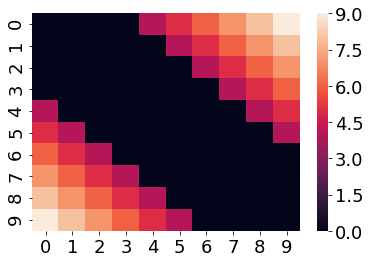

In [71]:
sns.heatmap(np.multiply(toeplitz(np.arange(10)), temporal_filter(10, -3)))

In [47]:
include_timepoints = 'all'
raise Exception(f'Invalid option for include_timepoints: \'{include_timepoints}\'.  Must be one of: \'all\', \'pre\', or \'post\'')

Exception: Invalid option for include_timepoints: 'all'.  Must be one of: 'all', 'pre', or 'post'

In [51]:
np.tril(toeplitz(np.arange(1, 11)), 1)
#use this to limit weights to either BEFORE or AFTER the relevant time

array([[ 1,  2,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 2,  1,  2,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  2,  1,  2,  0,  0,  0,  0,  0,  0],
       [ 4,  3,  2,  1,  2,  0,  0,  0,  0,  0],
       [ 5,  4,  3,  2,  1,  2,  0,  0,  0,  0],
       [ 6,  5,  4,  3,  2,  1,  2,  0,  0,  0],
       [ 7,  6,  5,  4,  3,  2,  1,  2,  0,  0],
       [ 8,  7,  6,  5,  4,  3,  2,  1,  2,  0],
       [ 9,  8,  7,  6,  5,  4,  3,  2,  1,  2],
       [10,  9,  8,  7,  6,  5,  4,  3,  2,  1]])

In [39]:
np.sum(toeplitz(np.arange(10)) < 5/2, axis=1)

array([3, 4, 5, 5, 5, 5, 5, 5, 4, 3])

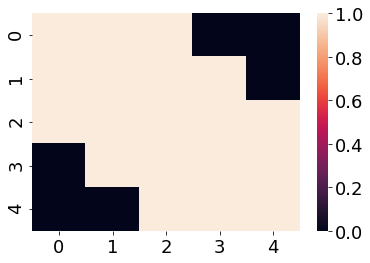

In [37]:
sns.heatmap(toeplitz(np.arange(5) < 5/2)) #not quite right for boxcar...

In [54]:
buffer = 30
r_f_nets = get_network_dynamics(data, [1, 2], weights_function=tc.gaussian_weights, weights_params={'var': 10}, combine=tc.helpers.corrmean_combine, before=buffer, after=buffer, offset=5)


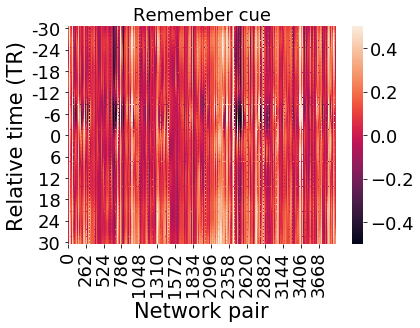

In [55]:
sns.heatmap(pd.DataFrame(r_f_nets[0], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Remember cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

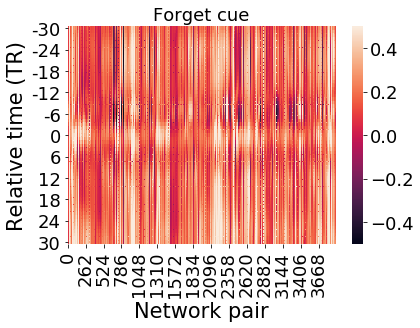

In [56]:
sns.heatmap(pd.DataFrame(r_f_nets[1], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Forget cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

(-10, 30)

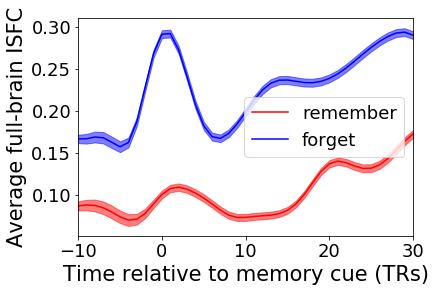

In [58]:
ts = np.arange(-buffer, buffer+1)
min_time = -10
max_time = 30

colors = ['r', 'b']
event_ribbon(r_f_nets[0], ts=ts, color=colors[0], limit_t=[min_time, max_time]);
event_ribbon(r_f_nets[1], ts=ts, color=colors[1], limit_t=[min_time, max_time]);
plt.legend(['remember', 'forget'])

plt.xlabel('Time relative to memory cue (TRs)')
plt.ylabel('Average full-brain ISFC')
plt.xlim([min_time, max_time])

In [59]:
eng = mlab.start_matlab()

In [60]:
def mlab_array(x):    
    return matlab.double(x.tolist())

In [61]:
def BrainNet_animation(centers, widths, connections, outfile):
    for i in np.arange(connections.shape[2]):
        next_fname = outfile + '_' + str(i) + '.jpg'
        if not os.path.exists(next_fname):
            eng.TFA_BrainNet_wrapper(mlab_array(centers), mlab_array(widths), mlab_array(np.squeeze(connections[:, :, i])), next_fname, os.path.join('data', 'brainnet_config_DF.mat'), nargout=0) #, next_fname)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [62]:
figdir = 'figs'
if not os.path.exists(figdir):
    os.makedirs(figdir)

BrainNet_animation(centers, widths, tc.vec2mat(r_f_nets[0]), os.path.join(figdir, 'remember'))
BrainNet_animation(centers, widths, tc.vec2mat(r_f_nets[1]), os.path.join(figdir, 'forget'))

In [71]:
!ffmpeg -r 10 -i figs/remember_%d.jpg figs/remember.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/remember_%d.jpg':
  Duration: 00:00:02.44, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/unknown/unknown), 2000x1500 [SAR 1:1

In [70]:
!ffmpeg -r 10 -i figs/forget_%d.jpg figs/forget.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/forget_%d.jpg':
  Duration: 00:00:02.44, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/unknown/unknown), 2000x1500 [SAR 1:1 D